In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
db=mysql.connector.connect(host="localhost",
                           username="root",
                           password="12345",
                           database="db_ecommercepython")
cur=db.cursor()


# 1.List all Unique cities where customers are located. 

In [105]:
query=""" select distinct(customer_city) as city from customers """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["city"])
df


,city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


## 2.count the number of orders placed in 2017 

In [106]:
query=""" SELECT count(order_id) FROM orders where year(order_purchase_timestamp) = 2017 """
cur.execute(query)
data=cur.fetchall()
"total orders placed in 2017 are",data[0][0]


('total orders placed in 2017 are', 45101)

## 3. Find the total sales per category.


In [107]:
query = """ select products.product_category Category,
round(sum(payments.payment_value),2) Sales
from products join order_items
on products.product_id=order_items.product_id 
join payments 
on payments.order_id=order_items.order_id
group by Category
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["Category","Sales"])
df


,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


## 4.Calculate the percentage of orders that were paid in installments

In [108]:
query=""" select (sum(case when payment_installments >=1 then 1 else 0 end))/count(*)*100 from payments """
cur.execute(query)
data=cur.fetchall()
"percentage of orders that were paid in installments",data[0][0]

('percentage of orders that were paid in installments', Decimal('99.9981'))

## 5.Count the number of customers from each state. 


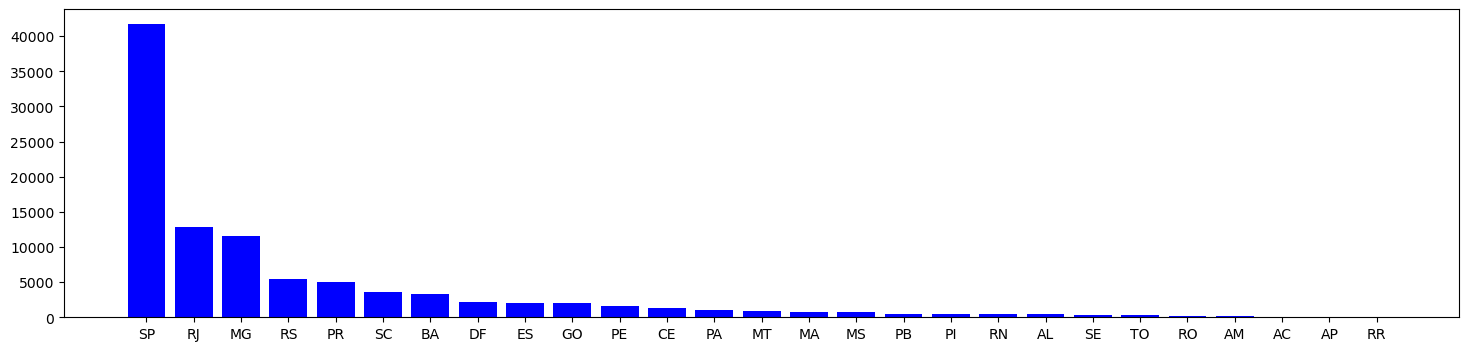

,Total_Customer,State
0,41746,SP
4,12852,RJ
2,11635,MG
5,5466,RS
3,5045,PR
1,3637,SC
9,3380,BA
13,2140,DF
8,2033,ES
7,2020,GO


In [109]:
query=""" select distinct count(customer_id) as Total_Customer,customer_state AS State  from customers group by customer_state """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Total_Customer","State"])
plt.figure(figsize=(18,4))
df= df.sort_values(by = "Total_Customer", ascending= False)
plt.bar(df["State"],df["Total_Customer"],color="blue")
plt.show()
df

## 6.Calculate the number of orders per month in 2018.


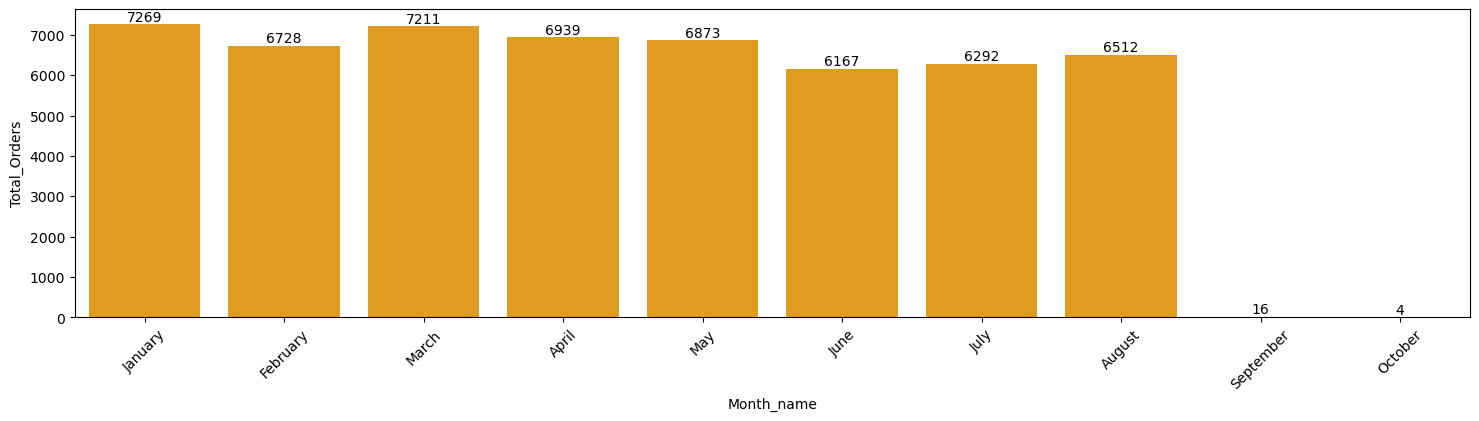

,Month_name,Total_Orders
0,July,6292
1,August,6512
2,February,6728
3,June,6167
4,March,7211
5,January,7269
6,May,6873
7,April,6939
8,September,16
9,October,4


In [110]:
query = """ SELECT  
MONTHNAME(order_purchase_timestamp) AS Month_name,
COUNT(order_id) AS Total_Orders
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2018
GROUP BY MONTHNAME(order_purchase_timestamp)
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["Month_name","Total_Orders"])
plt.figure(figsize=(18,4))
o=["January","February","March","April","May","June","July","August","September","October"]
ax = sns.barplot(x = df["Month_name"],y = df["Total_Orders"], data = df, order = o,color="orange")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.show()
df

## 7.Find the average number of products per order, grouped by customer city. 


In [111]:
query=""" WITH COUNT_PER_ORDER AS 
(SELECT ORDERS.ORDER_ID,ORDERS.CUSTOMER_ID,COUNT(ORDER_ITEMS.ORDER_ID) AS OC FROM ORDERS JOIN ORDER_ITEMS
ON ORDERS.ORDER_ID=ORDER_ITEMS.ORDER_ID
GROUP BY ORDERS.ORDER_ID,ORDERS.CUSTOMER_ID)

SELECT CUSTOMERS.CUSTOMER_CITY,round(avg(COUNT_PER_ORDER.OC),2) average_orders
FROM CUSTOMERS JOIN COUNT_PER_ORDER
ON CUSTOMERS.CUSTOMER_ID=COUNT_PER_ORDER.CUSTOMER_ID
GROUP BY CUSTOMERS.CUSTOMER_CITY order by average_orders desc """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Customer city","average Product"])
df.head(10)


,Customer city,average Product
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


## 8.Calculate the percentage of total revenue contributed by each product category.

In [112]:
query=""" SELECT upper(products.product_category) as Category,
round((SUM(payments.payment_value)/(select sum(payment_value) from payments))*100 ,2) as sales_percentage
FROM PRODUCTS 
 JOIN order_items 
 ON ORDER_ITEMS.product_id
=products.product_id
JOIN PAYMENTS 
ON PAYMENTS.ORDER_ID=order_items.order_id
 GROUP BY Category order by sales_percentage desc """
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["Category","sales_percentage"])
df.head(20)

,Category,sales_percentage
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
5,SPORT LEISURE,8.70
6,HOUSEWARES,6.84
7,AUTOMOTIVE,5.32
8,GARDEN TOOLS,5.24
9,COOL STUFF,4.87


## 9.Calculate the total revenue generated by each seller, and rank them by revenue.


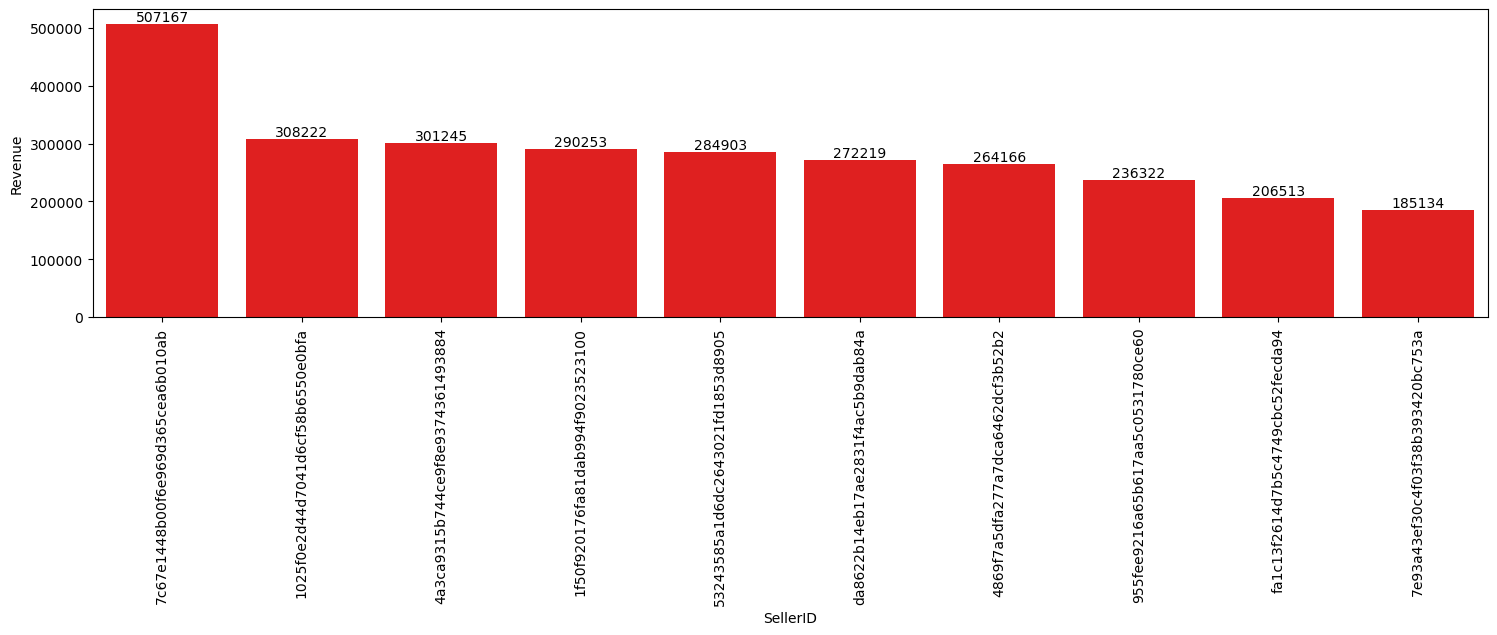

In [113]:
query=""" select *, dense_rank() over(order by Revenue desc) as Rn from (SELECT order_items.seller_id as Seller,round(sum(payments.payment_value),2) as Revenue
 from order_items join payments
on order_items.order_id=payments.order_id
group by Seller) as a """
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["SellerID", "Revenue", "Rank"])
df=df.head(10)
plt.figure(figsize=(18,4))
ax = sns.barplot(x = "SellerID",y = "Revenue", data = df,color="red")
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0])
plt.show()

## 10. Identify the top 3 customers who spent the most money in each year.

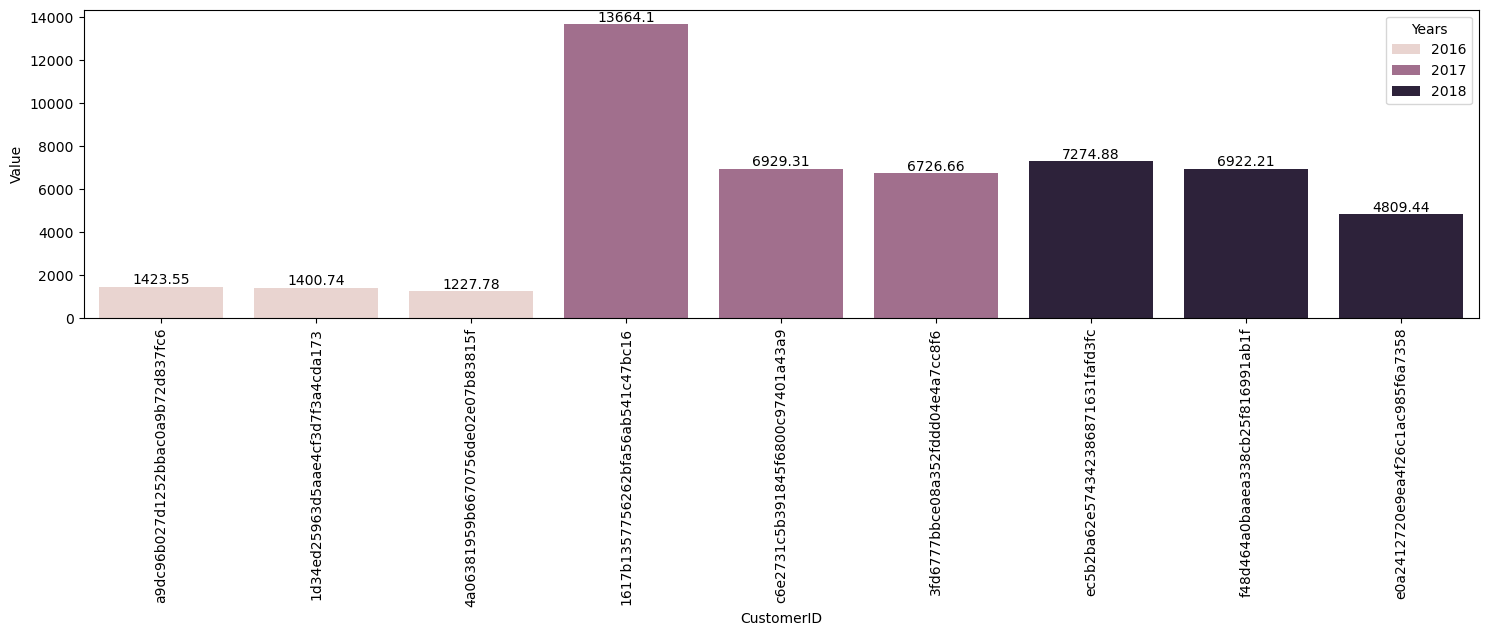

In [119]:
query=""" select year1,customer,pvalue,d_rank from
(select year(orders.order_Purchase_timestamp) as year1, orders.customer_id as customer, sum(payments.payment_value) as pvalue ,
dense_rank() over(partition by year(orders.order_Purchase_timestamp) order by sum(payments.payment_value) desc) d_rank
from 
orders join payments on orders.order_id=payments.order_id 
group by year1,customer) as a where d_rank <=3 """


cur.execute(query)
data=cur.fetchall()
plt.figure(figsize=(18,4))
df=pd.DataFrame(data,columns=["Years", "CustomerID", "Value","Rank"])
ax=sns.barplot(x = "CustomerID",y = "Value", data = df, hue="Years")
plt.xticks(rotation=90)
for container in ax.containers:ax.bar_label(container)
